# IN1160 – Oblig 3a: Beslutningstrær og maskinlæring i praksis

## Innlevering

Oppgaven leveres innen 15. april klokken 23.59 i [Devilry](https://devilry.ifi.uio.no/).

Innleveringen skal bestå av én Jupyter notebook med både kode og tilhørende forklaringer. **Før innlevering skal du kjøre gjennom hele notebooken, før du lagrer siste gang. Den bør kjøre uten å feile og vise den grafikken og de utskriftene som skal være med.**

Vi understreker at innlevering av kode alene ikke er nok for å bestå oppgaven – vi forventer at notebooken også skal inneholde kommentarer (på norsk eller engelsk) på hva dere har gjort og begrunnelser for valgene dere har tatt underveis.
La enhver oblig bli en trening i å formidle forskning. Bruk helst hele setninger, og matematiske formler om nødvendig. Resultater skal presenteres i tabeller på en oversiktlig måte.
Det å forklare med egne ord, bruke begreper vi har gått gjennom på forelesningene og å forklare og reflektere over løsningene deres er en viktig del av læringsprosessen – ta det på alvor!

Når det gjelder bruk av generative prateroboter (ChatGPT og lignende): Dere kan bruke dem som en "sparringspartner", for eksempel for å forklare noe dere ikke helt har forstått. Dere har imidlertid ikke lov til å bruke dem til å generere løsninger (enten delvis eller fullstendig) til noen av oppgavene. Funksjoner for automatisk skriving av kode, som Copilot i VS Code, må derfor også være deaktivert mens dere jobber på obligen.

Bruker dere KI-verktøy vil vi også at dere kort beskriver hvordan dere har brukt dem under arbeidet med oppgaven.

Det er ikke mulighet for omlevering av obliger som ikke bestås.

Her dere spørsmål til obligen eller finner noe dere tror er feil, må dere gjerne si ifra på [Discourse](https://discourse.uio.no/c/in1160-26v/820).



## Introduksjon

I denne obligen skal vi jobbe med [Titanic-datasettet](https://www.kaggle.com/competitions/titanic/data). Dette datasettet består av informasjon om passasjerene på Titanic, som kjønn, alder og deres billettpris, samt om de overlevde eller ikke. Målet vårt er å bruke ulike maskinlæringsmodeller til å predikere om en passasjer var sannsynlig til å overleve, basert på de andre trekkene i datasettet. Var det at "kvinner og barn først" eller var det første-klasse-passasjerer som hadde størst sjanse til å overleve?

Datasettet har flere kolonner, men vi skal fokusere på de følgende:

| Kolonnenavn | Beskrivelse                                                                              |
| ----------- | ---------------------------------------------------------------------------------------- |
| 'survived'  | Angir om passasjeren overlevde (1) eller døde (0)                                        |
| 'pclass'    | Angir passasjerens billettklasse, altså 1.-klasse (1), 2.-klasse (2) eller 3.-klasse (3) |
| 'sex'       | Mann (male) eller kvinne (female)                                                        |
| 'age'       | Alder i år                                                                               |
| 'fare'      | Passasjerens billettpris                                                                 |
| 'embarked'  | Angir om passasjeren reiste fra Southampton (S) eller Cherbourg (C) eller Queenstown (Q) |
| 'sibsp'     | Antall søsken/ektefelle passasjeren hadde ombord                                         |
| 'parch'     | Antall foreldre/barn passasjeren hadde ombord                                            |


I første omgang skal vi benytte oss av beslutningstrær, før vi sammenligner disse med andre algoritmer, som _k_-NN og nevrale nettverk.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seaborn import load_dataset
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score

### Frysing av tilfeldigheter

I cellen under setter vi NumPy sitt "seed" til tallverdien 1160. NumPy bruker mange "tilfeldige" verdier.
Ingenting er helt tilfeldig i datamaskiner, så disse verdiene blir valgt basert på algoritmer som skal simulere tilfeldighet. Algoritmene velger basert på et slikt seed, men dette vil endre seg fra kjøring til kjøring, så ved å "fryse" dette vil vi kunne få samme resultater for hver kjøring.  
Å gjøre dette er nyttig for oss når vi utvikler programmer, så vi får bedre oversikt over hva som skjer fra en gang til neste, men det er også viktig i vitenskapelig arbeid, siden det gjør resultatene våre etterprøvbare. 

Å fryse NumPy-tilfeldigheter er et viktig første steg, men mange av metodene, f.eks. `train_test_split()`, og klassene, f.eks. `DecisionTreeClassifier`, fra scikit-learn vi bruker i denne obligen bruker egne seeds. Disse har en ikke-obligatorisk parameter `random_state` som kan settes til et bestemt tall. 
En del av denne obligen blir å sørge for at alle metoder og klasser som har denne parameteren initialiseres med `random_state=1160`. Den beste kilden for å finne ut av disse parameterne er [den offisielle dokumentasjonen for scikit-learn](https://scikit-learn.org/stable/api/index.html). 


In [3]:
print("Før frysing:", np.random.randint(0, 1000), "(uforutsigbart)")
np.random.seed(1160)
print("Etter frysing:", np.random.randint(0, 1000), "(bør bli 373)")

Før frysing: 408 (uforutsigbart)
Etter frysing: 373 (bør bli 373)


## Oppgave 1

### Oppgave 1.1 – Forberede datasett (2 poeng)

Her laster vi inn datasettet ved bruk av funksjonen `load_dataset()`. Dette gir oss en `pandas.DataFrame` med dataene. 
Denne består stort sett av numeriske data, men kolonnene 'sex' og 'embarked' har strenger som verdier. Disse må gjøres om til numeriske verdier før vi kan bruke dem i modellene våre. For eksempel kan vi gjøre om 'male' til 0 og 'female' til 1. Til dette kan dere bruke metoden `.map()`.

I tillegg mangler noen av radene en verdi. Dette gjelder 'age'-kolonnen og 'embarked'-kolonnen. 
For å håndtere dette skal vi for 'age' fylle inn manglende verdier med medianalderen til alle passasjerene. Her kan metodene `.median()` og `.fillna()` være nyttige. 
For 'embarked' skal vi fylle inn manglende verdier med det mest vanlige utfartsstedet.

I denne oppgaven skal dere:
- Hente ut de relevante kolonnene fra datasettet (gjengitt i `wanted_features`).
- Gjøre om kategoriske data til numeriske verdier.
- Fylle inn manglende verdier som beskrevet over.
- Hente ut målkategorien 'survived'.

Hvis dere trenger hjelp med å jobbe med `DataFrames` kan dere ta en kikk på [pandas-dokumentasjonen](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html). Dere kan også se på [denne introduksjonen](../../ressurser/uke01-introduksjon/01bonus_pandas_plotly_tutorial.ipynb).

In [4]:
# Oppgave 1.1

# LAster inn Titanic-datasettet fra seaborn
df = load_dataset('titanic')

# Dette er kolonenen vi skal bruke som forkalringsvariabler (features)
wanted_features = ['pclass', 'sex', 'age', 'fare', 'embarked', 'sibsp', 'parch']

# Vi lager en kopi av de relevante kolonnene.
# Funksjonen .copy() er hensiktsmessig når vi senere skal endre på verdiene
X = df[wanted_features].copy()

# Mål-kategorien vi predikerer er passasjerer som overlever eller ikke.
y = df['survived']

# Gjør om verdier som er string til int
# Siden maskinlæringsmodeller i scikit-learn ikke jobber direkte på
# tekstverdier, så konverterer vi dem til numeriske verdier.
# sex: male -> 0 sex: female -> 1
X['sex'] = X['sex'].map({'male': 0, 'female': 1})

# embarked: S -> 0, C -> 1, Q -> 2
X['embarked'] = X['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Fyller inn de manglende verdiene.
# Det er som nevnt tidligere manglende verdier i 'age' og disse må fylles.
# Fylles med Medianen i aldersfordelingen, median kan være hensiktsmessig
# når vi har med å gjøre ekstreme utliggere.
median_age = X['age'].median()
X['age'] = X['age'].fillna(median_age)

# I 'embarked' er det også manglende verdier og her fyller vi inn med
# de "vanligste" verdiene, ved bruk av mode() funksjonen
common_embarked = X['embarked'].mode()[0]
X['embarked'] = X['embarked'].fillna(common_embarked)

# Sjekk for at manglende verdier ikke finnes lenger
print("Antall menglende verdier i hver kolonne er nå: ")
print(X.isna().sum())

print("\nFørste fem rader i det ferdige feature-settet er: ")
print(X.head())

print("\nFørste fem verdier i målkategorien y: ")
print(y.head())

Antall menglende verdier i hver kolonne er nå: 
pclass      0
sex         0
age         0
fare        0
embarked    0
sibsp       0
parch       0
dtype: int64

Første fem rader i det ferdige feature-settet er: 
   pclass  sex   age     fare  embarked  sibsp  parch
0       3    0  22.0   7.2500       0.0      1      0
1       1    1  38.0  71.2833       1.0      1      0
2       3    1  26.0   7.9250       0.0      0      0
3       1    1  35.0  53.1000       0.0      1      0
4       3    0  35.0   8.0500       0.0      0      0

Første fem verdier i målkategorien y: 
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


### Oppgave 1.2 – Oppdeling av datasett (1 poeng)

Dere skal nå dele opp i en treningssplitt og en testsplitt. Dere kan bruke `train_test_split()` til dette. Skriv så ut størrelsen av de to splittene.  
Vi skal bruke 80% av dataene til trening og 20% som testdata.

Husk å sette `random_state`! 

In [5]:
# Oppgave 1.2
# Deler datasetettet i treningsdata og testdata.
# test_size=0.2 betyr at vi fordeler 20% av de annoterte dataene til å være
# testdata og 80% til treningsdata. random_state=1160 gjør at vi får den
# samme tilfeldige oppdelingen hver gang vi kjører simuleringen.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1160
)

# Skriver ut informasjon for verifiseringen
print("\nStørrelse på treningssettet (X_train):", X_train.shape)
print("Størrelse på testsettet (X_test):", X_test.shape)
print("Størrelse på treningsmålet (y_train):", y_train.shape)
print("Størrelse på testmålet (y_test):", y_test.shape)



Størrelse på treningssettet (X_train): (712, 7)
Størrelse på testsettet (X_test): (179, 7)
Størrelse på treningsmålet (y_train): (712,)
Størrelse på testmålet (y_test): (179,)


### Forklaring Oppgave 1.1 og 1.2
Datasettet ble først gjort reproduserbart ved å fryse tilfeldighetene med kommandoen np.random.seed(1160). Før frysingen fikk vi verdien 859, mens etter ble det til 373, noe som viser at tilfeldighetene nå er faste og at samme resultat er å forvente for hver fremtidige simulering. Dette er såklart viktig for å kunne etterprøve resultatene.

Datasettet ble så klargjort for å hente ut de relevante variablene, nemlig: pclass, sex, age, fare, embarked, sibsp, parch. Streng variablene ble konvertert til numeriske verdier, slik at de kunne bli brukt i maskinlæringsalgoritmen i sckiti-learn, som kun tillatter numeriske verdier. 
Manglende variebler ble håndtert ved at de ble fylt med medianverdier og de mest vanlige verdiene.
Testet at utfyllingen fungerte, der vi kan se at kolonnene alle har 0 i verdi, som indikerer at datasettet er komplett uten hull.

De første fem radene i feature-settet viser at alle variablene nå er på numerisk form. For eksempel er kjønn kodet som tall, og embarked er også representert numerisk. De første fem verdiene i målkategorien y viser om passasjeren overlevde (1) eller ikke (0).

Til slutt ble datasettet delt inn i et treningssett og et testsett med en 80/20-fordeling. Treningssettet X_train fikk størrelsen (712, 7), mens testsettet X_test fikk størrelsen (179, 7). Tilsvarende fikk y_train 712 verdier og y-test 179 verdier. Dette betyr altså at vi nå har en passende oppdeling der modellen kan trenes på mesteparten av dataene og testes på resten.

## Oppgave 2 – Tre-trening

### Oppgave 2.1 – Et ubegrenset tre (2 poeng)

Vi skal trene en `DecisionTreeClassifier`. Her skal dere ikke ta noen form for hensyn til høyde på treet eller andre typer regularisering.

I denne oppgaven skal dere:

1. Opprette en `DecisionTreeClassifier` og trene den med `.fit()`.
2. Finne ut hvor høyt treet blir og hvor mange løvnoder det får.
3. Gjøre prediksjoner på både trenings- og testsett.
4. Beregne nøyaktighet for treet på begge splittene. Rapporter resultatene i en markdown-celle med en kort kommentar om hva vi observerer.

In [6]:
# Oppgave 2.1

# Vi lager et beslutningstre uten regularisering, slik at vi ikke
# setter max_depth, min_samples_split, osv. Treet får vokse fritt
# så langt det lar seg gjøre.
unrestricted_tree = DecisionTreeClassifier(random_state=1160)

# Bruker funksjonen .fit() for å trene modellen på treningsdatasettet
unrestricted_tree.fit(X_train, y_train)

# Henter ut treets dybde, get_depth() gir treets nivåer
tree_depth = unrestricted_tree.get_depth()

# henter ut antall løvnoder, som gir oss en endelig klassifisering
num_leaves = unrestricted_tree.get_n_leaves()

print("--- Ubegrenset beslutningstre ---")
print("Høyde/dybde på treet:", tree_depth)
print("Antall løvnoder:", num_leaves)

# Prediksjoner på treningssettet
y_train_pred = unrestricted_tree.predict(X_train)

# Prediksjoner på testsettet
y_test_pred = unrestricted_tree.predict(X_test)

# funksjonen accuracy_score sammenligner fasit med modellens prediksjoner
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\n--- Nøyaktighet for ubegrenset tre ---")
print("Treningsnøyaktighet:", train_accuracy)
print("Testnøyaktighet:", test_accuracy)

# Dersom treningsnøyaktigheten er relativt høy, men testnøyaktigheten er relativt lav, så
# kan det tyde på overfitting (overtilpasning).
# Da har treet lært treningsdataene godt, men generaliserer dårligere til nye annoterte data.


--- Ubegrenset beslutningstre ---
Høyde/dybde på treet: 20
Antall løvnoder: 158

--- Nøyaktighet for ubegrenset tre ---
Treningsnøyaktighet: 0.9831460674157303
Testnøyaktighet: 0.7653631284916201


#### Oppgave 2.1 – Tekstbesvarelse

Det ubegrensede beslutningstreet fikk en dybde på 20 og 158 løvnoder, noe som tyder på at treet har blitt svært stort og detaljert. Treningsnøyaktigheten ble veldg høy, på rundt 0.983, mens testnøyaktigheten ble en del lavere, på rundt 0.765. Dette tyder altså på at modellen passer treningsdataene godt, men ikke generaliserer like godt til nye data. Vi observerer mye sannsynlig en overtilpasning (overfitting) her. Treet lærer altså mange detaljer og mønstre i treningssettet, men noen av disse mønstrene ser ikke ut til å være like nyttge på testsettet vårt. Resultatet viser derfor at et helt ubegrenset tre ofte blir for komplisert.


### Oppgave 2.2 – Visualisering (1 poeng)

Under har vi implementert en enkel plotting for beslutningstrær. Denne tar inn et trent tre og lista over trekkene som ble brukt under trening. Den har også et ikke-obligatorisk parameter `max_depth` som er satt til 3. Dette er for å unngå visualiseringer av trær med veldig mange løvnoder.

Her skal dere gjøre en visualisering av treet med `max_depth` fortsatt på 3. Beskriv hva dere ser. Kan vi bruke treet til å fastslå hva majoritetsklassen er? Hvilke trekk benytter modellen seg av først? 

In [7]:
def visualize_tree(decision_tree, column_names, max_depth=3):
    plt.figure(figsize=(16, 8))
    plot_tree(
        decision_tree,
        max_depth=max_depth,
        feature_names=column_names,
        class_names=['died', 'survived'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f"Decision Tree with max depth {decision_tree.get_depth()}")
    plt.tight_layout()
    plt.show()

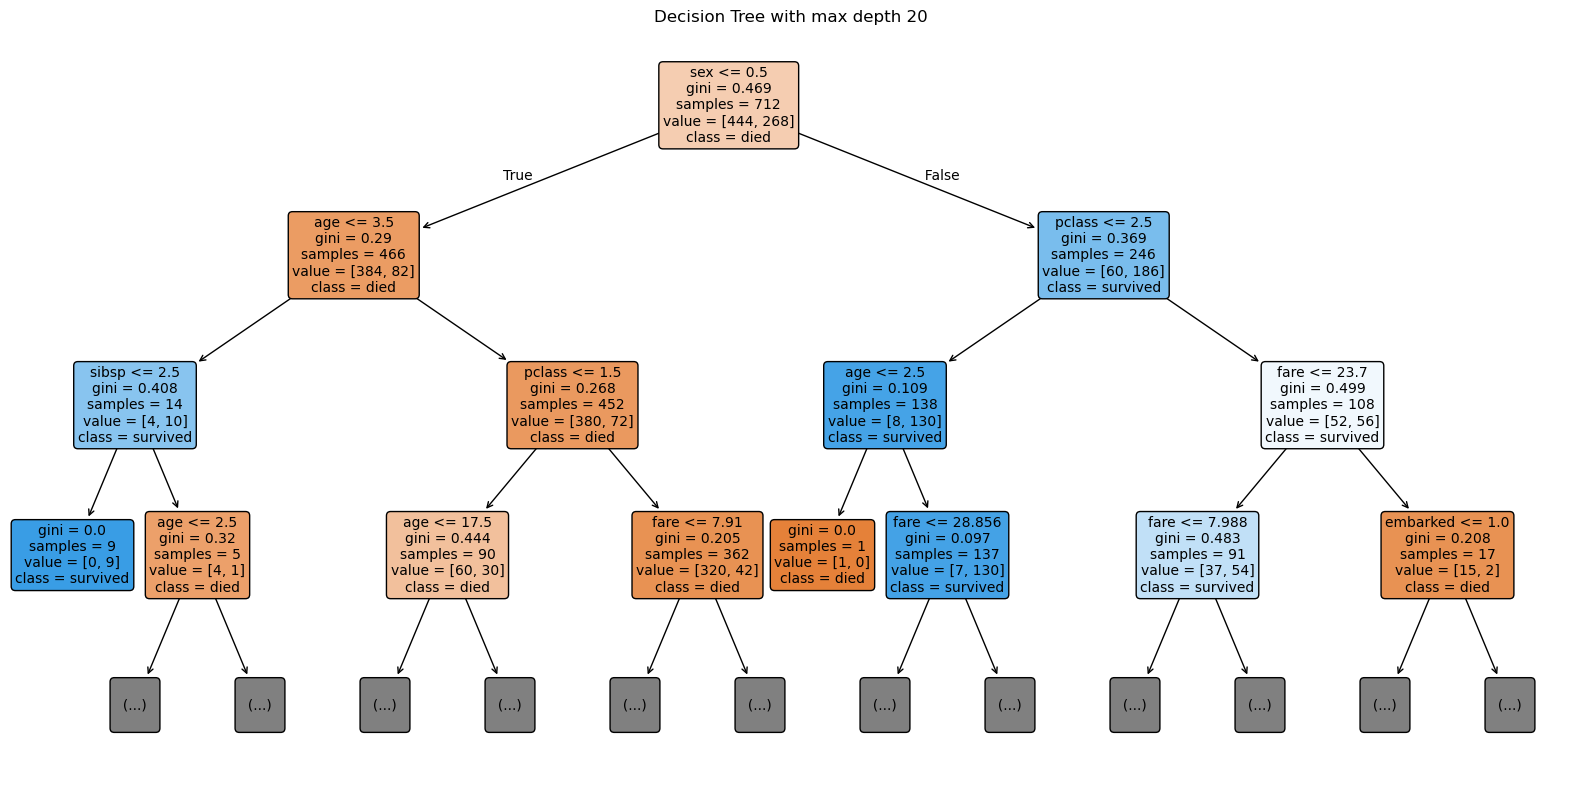

In [8]:
# Oppgave 2.2
# Visualisering av det trente treet.
visualize_tree(unrestricted_tree, X.columns, max_depth=3)

#### Oppgave 2.2 – Tekstbesvarelse

Visualiseringen viser at modellen først pslitter på variabelen 'sex'. Dette betyr at kjønn er det trekket modellen vurderer som viktigst helt i starten. Rotnoden har verdiene value = [444, 268] og klassen died, som viser at majoritetsklassen i treningsdatasettet er at passasjeren ikke overlever. Vi har dermed fastslått at majoritetsklassen er de som ikke overlevde ved å se på treets rotnode.

Videre ser vi at treet bruker trekk som age, pclass, fare, sibsp og embarked. På venstre side av treet, der sex <= 0.5, som altså tilsvarer menn, ser vi at mange noder klassifiseres som died. På høyre side derimot som tilsvarer female (kvinner), så ser vi flere forekomster av survived. Kjønn har ut ifra visualiseringen en stor betydning på om de overlevde eller ikke. Samtidig ser vi at alder og bilettpriser spiller en rolle. Ut ifra tre-visualiseringen, kan vi trekke konklusjonen at kjønn, alder (små barn) og bilettpris (høyere prisklasse) førte til økt sannsynlighet for å overleve.



### Oppgave 2.3 – Regularisering (3 poeng)

Dere skal nå lage nye trær med begrenset høyde. Bruk høydene spesifisert i lista `tree_depths` til å trene trær. Lag en tabell der dere for hver høyde noterer resultatene for nøyaktighet for både treningsdataene og testdataene, samt hvor mange løvnoder hvert tre får.


In [9]:
# Oppgave 2.3
tree_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, None]
results = []

for depth in tree_depths:
    # Lager et nytt tre for hver av dybdene i listen
    tree_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=1160
    )

    # Trener treet på treningsdataene:
    tree_model.fit(X_train, y_train)

    # Prediksjoner på trenings- og testsett
    train_pred = tree_model.predict(X_train)
    test_pred = tree_model.predict(X_test)

    # Beregner nøyaktigheten for modellene
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Henter antall løvnoder
    leaves = tree_model.get_n_leaves()

    # Lagrer resultatene i en liste med ordbøker
    results.append({
        'max_depth': depth,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'num_leaves': leaves
    })

# Gjør resultat ordboken om til en DateFrame for å visulisere det enklere:
results_df = pd.DataFrame(results)

print("\n--- Resultattabellen for regulariserte trær ---:")
print(results_df)



--- Resultattabellen for regulariserte trær ---:
    max_depth  train_accuracy  test_accuracy  num_leaves
0         2.0        0.808989       0.743017           4
1         3.0        0.832865       0.782123           8
2         4.0        0.839888       0.770950          14
3         5.0        0.856742       0.782123          22
4         6.0        0.866573       0.787709          32
5         7.0        0.891854       0.759777          45
6         8.0        0.897472       0.793296          58
7         9.0        0.922753       0.759777          75
8        10.0        0.939607       0.765363          91
9        15.0        0.974719       0.765363         141
10        NaN        0.983146       0.765363         158


### Forklaring Oppgave 2.3

Resultattabellen viser tydelig hvordan regularisering med max_depth påvirker både nøyaktighet og kompleksitet. Når treet er veldig grunt, for eksempel med dybde 2 eller 3, så er både treningsnøyaktigheten og testnøyaktigheten relativt lave, og treet har også få løvnoder. Dette betyr at modellen er enkel og lett å tolke, men at den ikke klarer å fange opp nok mønster i dataene.

Når dybden øker, så øker treningsnøyaktigheten jevnt, siden treet lærer mer detaljerte regler. Testnøyaktigheten øker også i starten, og de beste resultatene ser vi rundt moderate dybder. I denne tabellen er den høyeste testnøyaktigheten ved max_depth=8, med testnøyaktighet på omtrent 0.793 og 58 løvnoder. Dette tyder på at denne modellen gir en god balanse mekkom å lære monstre i treningsdataene og samtidig generalisere godt til testdata.

Når treet blir enda dypere, fortsetter treningsnøyaktigheten å øke kraftig, men testnøyaktigheten går ikke opp tilsvarende, og faller flere steder tilbake. For eksempel ser vi at ved dybde 15 og ved det ubegrensede treet at treningsnøyaktigheten blir svært høy, mens testnøyaktigheten ligger lavere enn for flere av de mindre trærne. Dette er et tegn på overtilpasning. Modellen blir fa for spesialtilpasset treningsdataene.

Tabellen viser altså at regularisering er nyttig fordi den kan hindre at treet blir unødvendig komplisert. Et mellomstort tre ser her ut til å fungere best, mens et veldig dypt eller helt ubegrenset tre gir høy treningsnøyaktighet, men svakere generalisering. Dette er et godt eksempel på at den mdoellen som lærer treningsdatene best ikke nødvendigvis er den som gjør det best på nye annoterte test data.

### Oppgave 2.4 – Kryssvalidering (2 poeng)

Så langt har vi delt dataene våre én gang i trenings- og testsett. Av og til kan vi være uheldige og få en oppdeling som får modellen vår til å se bedre (eller dårligere) ut enn den egentlig er. Vi kan løse dette med _kryssvalidering_ (engelsk: cross-validation) av dataene.  

Under kryssvalidering deler vi opp dataene flere ganger på forskjellige måter, slik at hver del av datasettet får prøvd seg som både treningssplitt og testsplitt. Vi trener modellen tilsvarende antall ganger og kommer fram til vårt endelige svar ved å ta gjennomsnittet av resultatene.
Dette gir oss et mer pålitelig estimat av ytelsen enn én enkelt trenings-test-oppdeling.

Dere skal nå bruke `cross_val_score()` til å utføre fem-gangers kryssvalidering på et beslutningstre uten noen høydebegrensning. Antall biter vi ønsker å dele treningssettet opp i styres av parameteren `cv`. I tillegg må dere sette parameteren `scoring` til 'accuracy', ettersom vi bruker nøyaktighet som målestokk.  
Etter å ha gjort dette skal dere beregne og skrive ut gjennomsnittet og standardavviket for de fem oppdelingene.


In [10]:
# Oppgave 2.4

# Lager et beslutningstre uten begrensning på dybden.
# max_depth er ikke satt nå, så treet vokser fritt.
cv_tree = DecisionTreeClassifier(random_state=1160)

# funksjonen cross_val_score utfører kryssvalideringen.
# cv=5, betyr 5-fold kryssvalidering, der treningssettet
# deles opp i 5 deler, og modellen trenes 5 ganger, og
# der hver del brukes én gang som valideringsdel.
# scoring='accuracy' betyr at vi måler nøyaktigheten
cv_scores = cross_val_score(
    cv_tree,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Regner gjennomsnittet for modellens ytelse
cv_mean = cv_scores.mean()

# Standardavviket forteller hvor mye variasjon det er
cv_std = cv_scores.std()

print("--- 5-gang kryssvalidering for ubegrenset tre ---")
print("Nøyaktighet i hver fold:", cv_scores)
print("Gjennomsnittlig nøyaktighet:", cv_mean)
print("Standardavvik:", cv_std)

# Høyt gjennomsnitt = modellen gjør det generelt bra
# lavt standardavvik = modellen er stabil mellom ulike oppdelinger
# høyt standradavvik = resultatene varierer mye -> usikker modellvurdering

--- 5-gang kryssvalidering for ubegrenset tre ---
Nøyaktighet i hver fold: [0.78321678 0.82517483 0.78169014 0.78169014 0.72535211]
Gjennomsnittlig nøyaktighet: 0.7794248005515612
Standardavvik: 0.03175393831616849


### Oppgave 2.5 – Trehøyde med kryssvalidering (2 poeng)

Dere skal nå teste forskjellige trehøyder/tredybder ved hjelp av kryssvalidering.  
Dette gjør dere ved å:

1. Gå gjennom de forskjellige `max_depth`-verdiene i `tree_depths`.
2. Utføre kryssvalidering for hver dybde.
3. Registrere gjennomsnittlig kryssvalidering.

Til slutt skal dere trene et siste tre der dere bruker den beste dybdeparameteren dere fant. Dere skal nå trene på hele treningssettet og teste mot de originale testdataene. Rapporter nøyaktighet for både treningsdataene og testdataene.

In [11]:
# Oppgave 2.5
tree_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, None]

# Tester ulike dybder for å finne hvilken max_depth som fungerer best
cv_depth_results = []

for depth in tree_depths:
    # Lager et nytt tre for hver max_depth
    tree_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=1160
    )

    # 5-fold kryssvalidering på treningssettet
    scores = cross_val_score(
        tree_model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    # Lagrer resultatene slik at vi kan sammenligne dybdene
    cv_depth_results.append({
        'max_depth': depth,
        'cv_mean_accuracy': scores.mean(),
        'cv_std_accuracy': scores.std()
    })

# Gjør resultatene om til DataFrame format
cv_depth_df = pd.DataFrame(cv_depth_results)

print("\n--- Kryssvalidering for ulike tre-dybder ---")
print(cv_depth_df)
print("\n Avrundet tabell:")
print(cv_depth_df.round(4))

# Finner raden med høyest avg kryssvaliderings-acc
best_depth_index = cv_depth_df['cv_mean_accuracy'].idxmax()
best_depth = cv_depth_df.loc[best_depth_index, 'max_depth']

print("\n Beste max_depth basert på kryssvalidering:", best_depth)

# Nå trener vi et siste tre med den beste dybden
best_tree = DecisionTreeClassifier(
    max_depth=int(best_depth),
    random_state=1160
)

# Trener det beste treet på treningsdataen
best_tree.fit(X_train, y_train)

# Prediksjoner på treningssettet og testsettet
best_tree_train_pred = best_tree.predict(X_train)
best_tree_test_pred = best_tree.predict(X_test)

# Nøyaktighet
best_tree_train_acc = accuracy_score(y_train, best_tree_train_pred)
best_tree_test_acc = accuracy_score(y_test, best_tree_test_pred)

print("\n--- Sluttmodell: Beste beslutningstre ---")
print("Valgt max_depth", best_depth)
print("Treningsnøyaktighet", best_tree_train_acc)
print("Testnøyaktighet", best_tree_test_acc)

# Bruker kryssvalidering på treningssettet for å velge paramaeteren.
# Testsettet brukes for en siste, faktisk evaluering av modellen.



--- Kryssvalidering for ulike tre-dybder ---
    max_depth  cv_mean_accuracy  cv_std_accuracy
0         2.0          0.796316         0.029266
1         3.0          0.821570         0.023296
2         4.0          0.822969         0.025692
3         5.0          0.818773         0.026308
4         6.0          0.806047         0.043028
5         7.0          0.808933         0.020087
6         8.0          0.796287         0.019471
7         9.0          0.793460         0.028142
8        10.0          0.778046         0.021965
9        15.0          0.779435         0.033238
10        NaN          0.779425         0.031754

 Avrundet tabell:
    max_depth  cv_mean_accuracy  cv_std_accuracy
0         2.0            0.7963           0.0293
1         3.0            0.8216           0.0233
2         4.0            0.8230           0.0257
3         5.0            0.8188           0.0263
4         6.0            0.8060           0.0430
5         7.0            0.8089           0.0201
6   

### Oppgave 2.6 – Tilfeldige skoger (3 poeng)

Vi skal nå undersøke effekten av å bruke tilfeldige skoger (engelsk: _random forests_).
Dette er en såkalt ensemble-metode hvor vi oppretter en skog, altså mange trær, og lar dem "stemme" om svaret, i stedet for å stole på ett enkelt beslutningstre.  
For å gjøre dette skal vi bruke en `RandomForestClassifier` som skal bestå av 100 trær. Bruk den beste verdien for `max_depth` dere fant i forrige oppgave. 

Lag skogen med 100 trær, tren den og gjør prediksjoner. Hva er differansen på nøyaktighet mellom skogmodellen og treet med best høyde fra oppgaven over?

In [12]:
# Oppgave 2.6
# Lager RandomForestClassifier.
# En random forest består av mange beslutningstrær som stemmer over svaret.
# Gir ofte bedre generalisering enn ett enkelt tre.
best_depth_for_forest = int(best_depth)

forest_100 = RandomForestClassifier(
    n_estimators=100,
    max_depth=best_depth_for_forest,
    random_state=1160
)

# Trener skogen
forest_100.fit(X_train, y_train)

# Prediksjoner
forest_train_pred = forest_100.predict(X_train)
forest_test_pred = forest_100.predict(X_test)

# Nøyaktighet
forest_train_acc = accuracy_score(y_train, forest_train_pred)
forest_test_acc = accuracy_score(y_test, forest_test_pred)

# Differanse i testnøyaktighet mellom random og beste enkelt-tre
accuracy_diff = (forest_test_acc - best_tree_test_acc)

print("\n--- Random forest med 100 trær ---")
print("Brukt max_depth:", best_depth_for_forest)
print("Treningsnøyaktighet:", forest_train_acc)
print("Testnøyaktighet:", forest_test_acc)
print("Differansen i testnøyaktighet sammenlignet med beste tre:", accuracy_diff)
# Hvis random forest gjør det bedre enn enkelt-treet, så betyr det ogte at
# ensemble-metoden gir mer robuste prediksjoner. Hvis forskjellen er liten
# kan det komme av at enkelt-treet gjorde det ganske optimalt allerede.
# Random forest vil overtilpasse mindre enn ett enkelt dypt tre.



--- Random forest med 100 trær ---
Brukt max_depth: 4
Treningsnøyaktighet: 0.8497191011235955
Testnøyaktighet: 0.7877094972067039
Differansen i testnøyaktighet sammenlignet med beste tre: 0.016759776536312887


### Oppgave 2.7 – Skogbredde (2 poeng)

På samme måte som med dybde, kan vi undersøke hvor mange trær det er gunstig å bruke.  
Bruk verdiene i `n_trees_list` til å undersøke hvordan nøyaktigheten endrer seg basert på hvor mange trær vi har. Her skal dere bruke kryssvalidering på samme måte som i oppgave **2.5**. Også her skal dere avslutningsvis trene en skog med de beste parameterne og alle treningsdataene, før dere måler ytelse på testsettet. 

In [13]:
# Oppgave 2.7
# Tester hvor mange trær som er gunstig å bruke. Dette er tilsvarende
# med å teste bredden på skogen.
n_trees_list = [1, 5, 10, 20, 35, 50, 75, 100, 200, 500, 1000]

# Bruker kryssvalideringe til å teste dette
forest_width_results = []

for n_trees in n_trees_list:
    forest_model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=best_depth_for_forest,
        random_state=1160
    )

    scores = cross_val_score(
        forest_model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    forest_width_results.append({
        'n_estimators': n_trees,
        'cv_mean_accuracy': scores.mean(),
        'cv_std_accuracy': scores.std()
    })

forest_width_df = pd.DataFrame(forest_width_results)

print("\n--- Kryssvalidering for ulike antall trær ---")
print(forest_width_df)
print("\nAvrundet tabell:")
print(forest_width_df.round(4))

# Finer antall trær som gir høyest avg kryssvaliderings acc
best_n_trees_index = forest_width_df['cv_mean_accuracy'].idxmax()
best_n_trees = int(forest_width_df.loc[best_n_trees_index, 'n_estimators'])

print("\nBeste antall trær basert på kryssvalidering:", best_n_trees)

# Trener en random forest med beste max_depth fra oppg. 2.5 og beste
# n_estimators fra oppg. 2.7:
final_forest = RandomForestClassifier(
    n_estimators=best_n_trees,
    max_depth=best_depth_for_forest,
    random_state=1160
)

final_forest.fit(X_train, y_train)

# Prediksjoner
final_forest_train_pred = final_forest.predict(X_train)
final_forest_test_pred = final_forest.predict(X_test)

# Nøyaktighet
final_forest_train_acc = accuracy_score(y_train, final_forest_train_pred)
final_forest_test_acc = accuracy_score(y_test, final_forest_test_pred)

print("\n--- Final Random forest ---")
print("Beste max_depth:", best_depth_for_forest)
print("Beste n_estimators:", best_n_trees)
print("Treningsnøyaktighet:", final_forest_train_acc)
print("Testnøyaktighet:", final_forest_test_acc)



--- Kryssvalidering for ulike antall trær ---
    n_estimators  cv_mean_accuracy  cv_std_accuracy
0              1          0.789343         0.031571
1              5          0.814567         0.021406
2             10          0.820171         0.018577
3             20          0.828612         0.016136
4             35          0.820181         0.023201
5             50          0.827194         0.025660
6             75          0.825785         0.025991
7            100          0.822969         0.027519
8            200          0.821580         0.022825
9            500          0.825795         0.023554
10          1000          0.822969         0.025692

Avrundet tabell:
    n_estimators  cv_mean_accuracy  cv_std_accuracy
0              1            0.7893           0.0316
1              5            0.8146           0.0214
2             10            0.8202           0.0186
3             20            0.8286           0.0161
4             35            0.8202           0.0232

### Forklaring Oppgave 2.4-2.7

#### Forklaring Oppgave 2.4 - Kryssvalidering av ubegrenset tre

I denne oppgaven bruktes 5-fold kryssvalidering på et ubegrenset beslutningstre for å få et mer pålitelig mål på modellens ytelse. I stedet for å stole på én enkelt oppdeling av dataene, deler kryssvalidering treningssettet i fem deler og trener modellen flere ganger, slik at hver del får være valideringsdataen én gang hver. Dette gjør resultat mer robust, men er mer ressurskrevende.

Resultatene for de fem foldene var 0.783, 0.825, 0.782, 0.782 og 0.725. Gjennomsnittlig nøyaktighet ble omtrent 0.779, og standardavviket ble omtrent 0.032. Dette betyr at modellen i snitt gjør det rimelig bra, men at ytelsen varierer noe mellom de ulike oppdelingene. Standardavviket er ikke veldig stort, men heller ikke lavt, så modellen kan virke brukbar uten at den da er helt stabil.

Det viktigste å legge merke til er at kryssvalideringsresultatet ligger nær testnøyaktigheten vi tidligere fikk for det ubegrensede treet. Samtidig viser kryssvalideringen tydligere at resultatet kan variere fra oppdeling til oppdeling. Dette er på grunnen til at kryssvalidering er nyttig, siden den gir et bedre estimat av hvor god modellen faktisk er enn bare én enkelt train/test-splitt.

Kryssvalidering brukes for å få en mer rettferdig og stabil vurdering av modellen. Gjennomsnittet sier noe om foventet ytelse, mens standardavviket sier noe om hvor stabil modellen er mellom ulike datapunkt.

#### Oppgave 2.5 - Trehøyde med kryssvalidering

I denne oppgaven testet vi ulike verdier for max_depth ved hjelp av kryssvalidering, for å finne hvilken trehøyde som gir best generalisering. Målet var å finne en modell som verken er for enkelt eller for komplisert.

Tabellen viser at de grunneste trærne, som med dybde=2, gir lavere nøyaktighet enn de med flere for de andre modellene. Dette tyder altså på at trærne blir for enkle og dermed ikke klarer å fange opp nok mønstre i dataene. Når vi så øker dybden til 3-4, så forbedres resultatene tydlig. Den beste gjennomsnittlige kryssvalideringsnøyaktigheten fikk vi ved max_depth=4, med en verdi på omtrent 0.823. Standardavviker her var omtrent 0.026, som betyr at modellen også er ganske stabil.

Når dybden øker videre, ser vi at resultatene ikke fortsetter å bli bedre. Tvert imot syngker den gjennomsnittlige kryssvalideringsnøyaktigheten for mange av de dypere trærne. Dette tyder på at. dypere trær begynner å overtilpasse treningsdatene. Et svært dypt tre vil lære mange flere detaljer og spesialtilfeller, men det er ikke sikkert at det er særlig nyttig for ny annotert data.

Etter den beste dybden ble funnet med kryssvalideringen, trentes et siste beslutningstre med max_depth=4 på hele treningssettet. Dette treet fikk en treningsnøyaktighet på rundt 0.840 og testnøyaktighet på rundt 0.771. Det viser da at modellen gjør det bra på treningsdataene, men fortsattt generaliserer greit til testdatene uten å være for komplekst.

Det som er viktig å merke seg er da at treet er bedre balansert enn det ubegrensede treet. I en tidligere deloppgave over, så hadde det ubegrensede treet høy treningsnøyaktighet, men en svakere generalisering. her har vi derimot fått lavere treningsnøyaktighet, men en modell som er enklere og og mer kontrollert.

#### Oppgave 2.6 - Tilfeldige skoger

I denne oppgaven sammenlignet vi det beste beslutningstreet med en random forest med 100 trær. En random forest er en ensemble-metode der mange beslutningtrår trener på litt ulike deler av dataene og deretter stemmer over svaret. Dette gjør modellen mindre sårbar for tilfeldige feil og overtilpasning i ett enkelt tre.

Vi brukte den beste dybden fra forrige oppgave, altså max_depth=4, også i random forest-modellen. Resultatet ble treningsnøyaktighet på rundt 0.850 og testnøyaktighet på rundt 0.788. Sammenlignet med det beste enkelt-treet, som hadde testnøyaktighet på 0.771, er dette en forbedring på rundt 0.0168, altså rundt 1.7 prosent.

Dette viser at random forest-modellen generaliserer bedre enn ett enkelt beslutningstre. Selv om forskjellen ikke er enorm, er den tydlig nok til å vise poenget med ensemble-metoder. Når mange trær samarbeider, blir prediksjonene ofte mer robuste enn når vi bruker ett enkelt tre alene.

#### Oppgave 2.7 - Skogbredde

I denne oppgaven undersøkte vi hvor mange trær som er gunstig å bruke i en random forest. Vi testet ulike verdier for n_estimators med kryssvalidering, på samme måte som vi testet max_depth i forrige oppgave.

Tabellen viser at en skog med bare 1 tre gir lavest resultat, med gjennomsnittlig kryssvalideringsnøyaktighet på omtrent 0.789. Det er naturlig, siden én tre-modell i praksis are er et enkelt beslutningstre og ikke får fordelen av ensemble-metoden. Når vi øker antall trær til 5, 10, og 20, så stiger nøyaktigheten. Den beste verdien fikk vi ved 20 trær, men gjennomsnittlig kryssvalideringsnøyaktighet på omtrent 0.829 og et relativt lavt standardavvik på omtrent 0.016.

Når vi øker antall trær videre til 35, 50, 75, 100, 200, 500, og 1000, så ser vi at resultatene ikke blir tydelig bedre som før. De holder seg gnaske nær samme nivå. Dette viser at det finnes et punkt der flere trær ikek lenger gir en betydelig gevinst. Etter et visst nivå så flater faktisk forbedringern seg ut, mens kjøretiden og ressursbruken fortsatt da øker.

Til slutt trentes en endelig random forest med de beste parameterene vi har funnet så langt, altså max_depth=4 og n_estimators=20. Denne modellen gikk treningsnøyaktighet på omtrent 0.848 og testnøyaktighet på omtrent 0.810. Dette er det beste testresultatet så langt. Det viser at kombinasjonen av en moderat tre-dybde og passe antall trær gir den beste generaliseringen, i denne simuleringen med disse annoterte trenings- og testdataene.

## Oppgave 3 – Måle mot andre modeller

I denne oppgaven skal vi sammenligne beslutningstrær med to andre modeller vi allerede har vært innom: _k_-NN og nevrale nettverk.

### Oppgave 3.1 – _k_-NN (2 poeng)

Her skal dere lage en _k_-NN-modell med `KNeighborsClassifier` som i oblig 1b. 

Her skal dere:

1. Finne den beste verdien for _k_ blant verdiene listet i `k_values`.
2. Gjøre prediksjoner og beregne nøyaktighet for både trenings- og testsett.
3. Rapportere resultatene i en markdown-celle.
4. Sammenligne resultatene med den beste skogen fra oppgave **2.7**.


In [14]:
# Oppgave 3.1
# Liste over k verdier vi skal teste
k_values = [1, 3, 5, 7, 10, 15, 20, 30, 50, 100]

# Lagrer resultatene for hver k-verdi:
knn_results = []

# Vi går gjennom alle verdiene i k_values
for k in k_values:
    # Lager en k-NN modell med k
    # n_neigbors = antall nærmeste naboer modellen skal bruke når den skal
    # klassifisere et nytt datapunkt
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Trener modellen på treningsdataene. k-NN "lærer" egentlig ikke en eksplisitt
    # modell på samme måte som et tre, men funksjonen .fit() kjøres for
    # at modellen skal lagre treningsdataene.
    knn_model.fit(X_train, y_train)

    # Prediksjoner på testsettet:
    train_pred = knn_model.predict(X_train)
    test_pred = knn_model.predict(X_test)

    # Nøyaktighet
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Lagrer resultatene
    knn_results.append({
        'k': k,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

# Gjør resultatene om til DataFrame
knn_results_df = pd.DataFrame(knn_results)

print("\n--- Results for k-NN ulike k-verdier ---")
print(knn_results_df)
print("\nAvrundet tabell:")
print(knn_results_df.round(4))

# ---- 1) Finner beste verdi for k -----
# idxmax() finner raden med høyest test_accuracy
best_k_index = knn_results_df['test_accuracy'].idxmax()

# Henter ut beste k-verdi
best_k = int(knn_results_df.loc[best_k_index, 'k'])

print("\nBeste verdi for k:", best_k)

# ---- 2) Trener sluttmodellen med beste k -----
best_knn = KNeighborsClassifier(n_neighbors=best_k)

# Trener modellen
best_knn.fit(X_train, y_train)

# Prediksjoner
best_knn_train_pred = best_knn.predict(X_train)
best_knn_test_pred = best_knn.predict(X_test)

# Nøyaktighet
best_knn_train_acc = accuracy_score(y_train, best_knn_train_pred)
best_knn_test_acc = accuracy_score(y_test, best_knn_test_pred)

print("\n--- Sluttmodell for k-NN ---")
print("Valgt k:", best_k)
print("Treningsnøyaktighet:", best_knn_train_acc)
print("Testnøyaktighet:", best_knn_test_acc)

# ---- 3) Sammenligning med beste random forest fra oppg. 2.7
print("\n--- Sammenligning med beste random forest ---")
print("k-NN testnøyaktighet:", best_knn_test_acc)
print("Random forest testnøyaktighet:", final_forest_test_acc)
print("Forskjell (k-NN minus random forest):", best_knn_test_acc - final_forest_test_acc)
# Hvis tallet blir negativt, random forest gjorde det bedre
# Hvis tallet blir positivt, k-NN gjorde det bedre
# Liten forskjell betyr lik ytelse i modellene



--- Results for k-NN ulike k-verdier ---
     k  train_accuracy  test_accuracy
0    1        0.981742       0.726257
1    3        0.834270       0.765363
2    5        0.789326       0.743017
3    7        0.773876       0.743017
4   10        0.755618       0.709497
5   15        0.742978       0.709497
6   20        0.734551       0.692737
7   30        0.702247       0.670391
8   50        0.696629       0.659218
9  100        0.689607       0.625698

Avrundet tabell:
     k  train_accuracy  test_accuracy
0    1          0.9817         0.7263
1    3          0.8343         0.7654
2    5          0.7893         0.7430
3    7          0.7739         0.7430
4   10          0.7556         0.7095
5   15          0.7430         0.7095
6   20          0.7346         0.6927
7   30          0.7022         0.6704
8   50          0.6966         0.6592
9  100          0.6896         0.6257

Beste verdi for k: 3

--- Sluttmodell for k-NN ---
Valgt k: 3
Treningsnøyaktighet: 0.8342696629213483
T

### Forklaring Oppgave 3.1

I denne oppgaven ble flere verdier for k testen i en k-NN modell for å finne hvilken som ga best resultat. Tabellen viser at treningsnøyaktigheten er den samme for alle verdiene, omtrent 0.983, mens testnøyaktigheten varierer en del. Den beste verdien for k bli k=3, med en testnøyaktighet på omtrent 0.765. Dette betyr at modellen med tre nærmeste naboer ga de beste prediksjonene på testsettet blant verdiene vi prøvde.

Vi ser også at testnøyaktigheten gradvis blir dårligere når k blir større. For eksempel synker den omtrent 0.765 ved k=3 til omtrent 0.626 ved k=100. Dette tyder på at når modellen tar hensyn til for mange naboer, blir den for grov og klarer ikke å skille klassene like godt. Samtidig ser vi at små verdier for k gir bedre resultater, men ikke nødvendigvis best ved k=1. I dette tilfellet ser k=3 ut til å gi den beste balansen.

Når vi sammenligner den beste random forest-modellen fra oppgave 2.7, ser vi at random forest gjorde det bedre. k-NN-modellen fikk testnøyaktighet på omtrent 0.765, mens random forest fikk omtrent 0.810. Forskjellen er rundt -0.045, noe som betyr at k-NN ligger rundt 4.5 prosent lavere enn random forest. Dette viser at random forest-modellen generaliserer bedre på dette datasettet enn k-NN.

### Oppgave 3.2 – Nevrale nettverk (2 poeng)

Dere skal nå lage en modell med et nevralt nettverk ved hjelp av `MLPClassifier`. Denne ligner langt på vei på den nevrale nettverksklassen dere benyttet dere av i oblig 2b, men har noen små forskjeller det kan være lurt å være klar over:

- De ulike lagene spesifiseres med parameteren `hidden_layer_sizes`. Denne tar en tuppel med antall noder i hvert lag, som f.eks. `(5, 10, 8)` for tre lag med henholdsvis 5, 10 og 8 noder.
- Aktiveringsfunksjonen spesifiseres med parameteren `activation`. Standardverdien for denne er `'relu'`. Denne implementasjonen kan bare bruke én aktiveringsfunksjon for alle lagene.
- Trening skjer som vanlig med metoden `.fit()`.

Her skal dere finne den beste sammensetningen av lag fra lista `hidden_sizes`. I denne oppgaven trenger dere ikke å gjøre kryssvalidering.
Sammenlign resultatene av det beste nevrale nettverket med de to andre modellene dere har laget så langt.


In [15]:
# Oppgave 3.2

# Liste over nettverksarkitekturer
# Eksempler: (5,) betyr ett skjult lag med 5 noder
# (25, 100, 25) betyr tre skjulte lage med 25 inputnoder,
# 100 noder i det skjulte laget og 25 noder i output laget
hidden_sizes = [
    (5,),
    (10,),
    (50,),
    (100,),
    (25, 25),
    (50, 50),
    (25, 100, 25)
]

# Lagrer resultatene
mlp_results = []

# Går gjennom kombinasjonene i hidden_sizes
for size in hidden_sizes:
    # Lager et nevralt nettverk,
    # hidden_layer_sizes = strukturen på de skjulte lagene,
    # activation='relu' standard og god i praksis,
    # max_iter antall treningsrunder modellen kan bruke
    mlp_model = MLPClassifier(
        hidden_layer_sizes=size,
        activation='relu',
        max_iter=1000,
        random_state=1160
    )

    # Trener modellen på treningsdataene
    mlp_model.fit(X_train, y_train)

    # Prediksjoner
    train_pred = mlp_model.predict(X_train)
    test_pred = mlp_model.predict(X_test)

    # Nøyaktighet
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Lagrer resultatene
    mlp_results.append({
        'hidden_layer_sizes': size,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

# Gjør om til DataFrame
mlp_results_df = pd.DataFrame(mlp_results)

print("--- Resultater for nevrale nettverk ---")
print(mlp_results_df)
print("\nAvrundet tabell:")
print(mlp_results_df.round(4))

# --- Beste arkitetkuren ---
# Finner raden med høyest test_accuracy
best_mlp_index = mlp_results_df['test_accuracy'].idxmax()

# Henter ut den beste lagstrukturen
best_hidden_size = mlp_results_df.loc[best_mlp_index, 'hidden_layer_sizes']

print("\nBeste hidden_layer_sizes:", best_hidden_size)

# --- Trener sluttmodellen med beste arkitektur ---
best_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden_size,
    activation='relu',
    max_iter=1000,
    random_state=1160
)

# Trener modellen
best_mlp.fit(X_train, y_train)

# Prediksjoner
best_mlp_train_pred = best_mlp.predict(X_train)
best_mlp_test_pred = best_mlp.predict(X_test)

# Nøyaktighet
best_mlp_train_acc = accuracy_score(y_train, best_mlp_train_pred)
best_mlp_test_acc = accuracy_score(y_test, best_mlp_test_pred)

print("\n--- Sluttmodell for nevralt nettverk ---")
print("Valgt hidden_layer_size:", best_hidden_size)
print("Treningsnøyaktighet:", best_mlp_train_acc)
print("Testnøyaktighet:", best_mlp_test_acc)

# --- Sammenligning med de to andre modellene ---
print("\n--- Sammenligning av modeller ---")
print("Nevralt nettverk testnøyaktighet:", best_mlp_test_acc)
print("k-NN testnøyaktighet:", best_knn_test_acc)
print("Random forest testnøyaktighet:", final_forest_test_acc)

print("\nForskjell mellom nevralt nettverk og k-NN:", best_mlp_test_acc - best_knn_test_acc)

print("\nForskjell mellom nevralt nettverk og random forest:",
    best_mlp_test_acc - final_forest_train_acc)

--- Resultater for nevrale nettverk ---
  hidden_layer_sizes  train_accuracy  test_accuracy
0               (5,)        0.810393       0.759777
1              (10,)        0.823034       0.759777
2              (50,)        0.824438       0.754190
3             (100,)        0.817416       0.737430
4           (25, 25)        0.834270       0.748603
5           (50, 50)        0.845506       0.787709
6      (25, 100, 25)        0.824438       0.782123

Avrundet tabell:
  hidden_layer_sizes  train_accuracy  test_accuracy
0               (5,)          0.8104         0.7598
1              (10,)          0.8230         0.7598
2              (50,)          0.8244         0.7542
3             (100,)          0.8174         0.7374
4           (25, 25)          0.8343         0.7486
5           (50, 50)          0.8455         0.7877
6      (25, 100, 25)          0.8244         0.7821

Beste hidden_layer_sizes: (50, 50)

--- Sluttmodell for nevralt nettverk ---
Valgt hidden_layer_size: (50, 50

### Forklaring Oppgave 3.2

I denne oppgaven testet vi flere ulike nevrale nettverk ved å variere hidden_layer_sizes, altså hvor mange skjulte alg og noder modellen skulle ha. Resultatene viser at både treingsnøyaktigheten og testnøyaktigheten varierte mellom modellene. Den beste arkitekturen ble (50, 50), altså to skjulte lag med 50 noder i hvert lag. Denne modellen fikk treningsnøyaktighet på omtrent 0.846 og testnøyaktighet på omtrent 0.846 og testnøyaktighet på rundt 0.788.

Sammenligned med de andre modellene gjorde det nevrale nettverket det bedre enn k-NN, som fikk testnøyaktighet på rundt 0.765, men dårligere enn random forest, som fikk rundt 0.810. Forskjellen mellom MLP og k-NN var omtrent 0.022, mens forskjellen mellom MLP og random forest var rundt -0.0061.

Dette viser at nevrale nettverk kan fungere bra på datasetet, men random forest fortsatt generaliserer bedre av modellene. Samtidig ser vi at en større og mer kompleks modell ikke nødvendigvis gir et mer markant bedre resultat enn enklere modeller.

### Oppgave 3.3 – Et sammensatt ensemble (2 poeng)

Vi har allerede undersøkt hvordan skoger av trær kan forbedre nøyaktigheten til beslutningstrær. 
I denne oppgaven skal vi videreutvikle vårt ensemble og kombinere skogen med de to andre modellene vi har laget.

For å gjøre dette skal dere bruke `VotingClassifier` fra scikit-learn. Denne klassen tar inn flere modeller i form av tupler på formatet `(navn, modell)`, der navn er en streng og modell er en klassifikasjonsmodell med de parameterne vi ønsker å bruke. 

Her skal dere sende inn en `KNeighborsClassifier`, en `MLPClassifier` og en `RandomForestClassifier`. Alle disse skal ha de beste parameterne dere har funnet i de foregående oppgavene.  
Tren så ensemble-modellen på treningsdataene (ingen kryssvalidering) og gjør prediksjoner på både trenings- og testdataene.

Beregn nøyaktighet på begge to og rapporter resultatene i en markdown-celle. Hvilken modell gjorde det best?


In [16]:
# Oppgave 3.3

# Lager modellene med de beste parameterene
# k-NN modellen med beste verdi for k
knn_best_model = KNeighborsClassifier(
    n_neighbors=best_k
)

# Nevralt nettverk med beste lagstruktur
mlp_best_model = MLPClassifier(
    hidden_layer_sizes=best_hidden_size,
    activation='relu',
    max_iter=1000,
    random_state=1160
)

# Random forest med beste dybde og beste antall trær
forest_best_model = RandomForestClassifier(
    n_estimators=best_n_trees,
    max_depth=best_depth_for_forest,
    random_state=1160
)

# Bruker modellene som var best og sammenligner resultatene

# Lager et ensemble med votingclassifier
# VotingClassifier kombinerer flere modeller.
# Hver modell stemmer på predikert riktig klassen.
ensemble_model = VotingClassifier(
    estimators=[
        ('knn', knn_best_model),
        ('mlp', mlp_best_model),
        ('forest', forest_best_model)
    ]
)

# Estimators er liste av tupler (navn, modell)
# navn er srteng id, modell er initialisert klassifikasjonsmodell

# Trener ensemble modellen
ensemble_model.fit(X_train, y_train)
# Nå er alle modellene trent som del av ensemblet.

# Gjør prediksjoner på treningsdata
ensemble_train_pred = ensemble_model.predict(X_train)
# Gjør prediksjoner på testdata
ensemble_test_pred = ensemble_model.predict(X_test)

# Nøyaktighet
ensemble_train_acc = accuracy_score(y_train, ensemble_train_pred)
ensemble_test_acc = accuracy_score(y_test, ensemble_test_pred)

print("--- Resultater for ensemble-modellen ---")
print("Treningsnøyaktighet:", ensemble_train_acc)
print("Testnøyaktighet:", ensemble_test_acc)

# --- Sammenligner med de andre modellene
comparison_df = pd.DataFrame(
    [
        {"model": "k-NN", "test_accuracy": best_knn_test_acc},
        {"model": "Neural Network (MLP)", "test_accuracy": best_mlp_test_acc},
        {"model": "Random Forest", "test_accuracy": final_forest_test_acc},
        {"model": "Voting Ensemble", "test_accuracy": ensemble_test_acc}
    ]
)

print("\n--- Sammenligning av modeller ---")
print(comparison_df.round(4))

# Finner modellen med høyest testnøyaktighet
best_model_index = comparison_df['test_accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_index, 'model']
best_model_acc = comparison_df.loc[best_model_index, 'test_accuracy']

print("\nModellen som gjorde det best:")
print("Navn:", best_model_name)
print("Testnøyaktighet:", best_model_acc)


--- Resultater for ensemble-modellen ---
Treningsnøyaktighet: 0.8581460674157303
Testnøyaktighet: 0.8379888268156425

--- Sammenligning av modeller ---
                  model  test_accuracy
0                  k-NN         0.7654
1  Neural Network (MLP)         0.7877
2         Random Forest         0.8101
3       Voting Ensemble         0.8380

Modellen som gjorde det best:
Navn: Voting Ensemble
Testnøyaktighet: 0.8379888268156425


### Forklaring Oppgave 3.3

I denne oppgaven kombinerte vi de tre beste modellene våre, k-NN, MLP og random forest, i et samlet ensemble ved hjelp av VotingClassifier. Ideen bak dette er at modellene kan utfylle hverandre ved at de gjør ulike typer feil, og den endelige prediksjonen blir valgt ut fra flertallsstemmer mellom modellene.

Ensemble-modellen fikk en treningsnøyaktighet på rundt 0.858 og en testnøyaktighet på rundt 0.838. Dette er det beste testresultatet vi har fått så langt. Sammenlignet med de individuelle modellene ser vi at ensemblet presterte bedre enn både k-NN, MLP og random forest alene.

I sammenligningstabellen ser vi at k-NN fikk en testnøyaktighet på omtrent 0.765, det nevrale nettverket fikk rundt 0.788, og random forest fikk rundt 0.810. Voting ensemble fikk på den andre siden 0.832, og ble dermed den bedre modellen. Dette tyder altså på at kombinasjonen av flere ulike modeller faktisk ga bedre generalisering enn hver enkelt modell klarer å oppnå alene.

Resultatet viser altså at ensemble-metoder kan være svært nyttige. Selv om random forest allerede var den beste enkeltmodellen, klarte voting ensemble å forbedre resultatet ytterligere. Dette er et godt eksempel på at flere modeller sammen ofte kan gi mer robuste og presise prediksjoner enn én modell alene.